# Prevalence Estimation with Inverse Probability Weighting & NPE

In [ ]:
import os
os.environ['KERAS_BACKEND'] = 'jax'

import itertools
import numpy as np
import pandas as pd
from scipy.special import expit as sigmoid

import matplotlib.pyplot as plt

import keras
import bayesflow as bf

from joblib import Parallel, delayed
import pickle

- Create a true population with infections, get a biased sample from it
- The biased sample represents the data we would get from an actual study
- From the true population, we pretend to know only the distribution of the covariates (and the infectiousness related with these, in a real application, we would also estimate these)
- Hence, we can create an approximation of the true population by stratified sampling from the biased sample

In [ ]:
# Known population parameters
age_probs = {'0-19': 0.168, '20-34': 0.25, '35-49': 0.223, '50-64': 0.187, '65-79': 0.118, '80+': 0.054}
gender_probs = {'male': 0.5, 'female': 0.5}
h_size_probs = {'household_1': 0.549, 'household_2': 0.226, 'household_34': 0.124, 'household_5+': 0.101}
country_probs = {'Germany': 1-0.35, 'other': 0.35}

cat_to_int = {
    'age': {'0-19': 1, '20-34': 2, '35-49': 3, '50-64': 4, '65-79': 5, '80+': 6},
    'gender': {'male': 1, 'female': 2},
    'h_size': {'household_1': 1, 'household_2': 2, 'household_34': 3, 'household_5+': 4},
    'country': {'Germany': 1, 'other': 2}
}

test_specificity_params = {  # (from Olbricht et al, 2020)
    'specificity': 0.9972041,
    'sensitivity': 0.8860104
}

In [ ]:
# 1. Sampling from priors
def get_realistic_priors():
    """
    With these priors, the uncorrected prevalence will generally be too low
    compared to the true population prevalence. This is because the sampling
    mechanism systematically underrepresents high-risk groups and overrepresents
    low-risk groups. The corrected prevalence using inverse probability weighting
    should compensate by giving more weight to the under-represented high-risk
    groups, resulting in a higher and more accurate estimate.

    Returns:
        infection_prior_means (dict): prior means for the log-odds model of infection
        infection_prior_stds  (dict): prior stds   for the log-odds model of infection
        inclusion_prior_means (dict): prior means for the log-odds model of inclusion
        inclusion_prior_stds  (dict): prior stds   for the log-odds model of inclusion
    """

    # — Infection model priors (logit scale) — #
    #   baseline intercept roughly expit(-3) ≈ 0.05
    infection_prior_means = {
        'intercept': -3.5,
        # pick 0-19 as reference, then increasing log-odds for older groups
        **{f'age_{g}': delta for g, delta in zip(
            list(age_probs.keys())[1:],
            [0.0, 0.5, 1.0, 1.5, 2.0, 2.5][1:]
        )},
        # pick male as reference (0), female slightly lower odds
        'gender_female': -0.3,
        # household_1 as reference (0), larger HH slightly higher risk
        **{f'h_size_{g}': delta for g, delta in zip(
            list(h_size_probs.keys())[1:],
            [0.0, 0.2, 0.4, 0.6][1:]
        )},
        # country Germany as reference
        'country_other': 0.0
    }
    # keep these fairly tight to encode our prior beliefs
    infection_prior_stds = {
        'intercept':     1.0,
        **{f'age_{g}': 0.5 for g in list(age_probs.keys())[1:]},
        'gender_female': 0.2,
        **{f'h_size_{g}': 0.4 for g in list(h_size_probs.keys())[1:]},
        'country_other': 0.2
    }

    # — Inclusion‐mechanism priors (logit scale) — #
    inclusion_prior_means = {
        'intercept':   -3.5, # -1,
        # older and young age less likely to respond
        **{f'age_{g}': delta for g, delta in zip(
            list(age_probs.keys())[1:],
            #[-0.1, 1.0, 1.0, 1.2, 1.0, 0.2]  # this is more similar to the PedCov
            #[0.0, -1.0, -2.0, -3.0, -4.0, -5.0]  # this is better for demonstration
            #[-1.0, 0.5, -0.5, -1.0, -2.0, -1.0][1:]
            [-1.0, 0.0, -0.5, -0.5, -1.0, -0.5][1:]
        )},
        # women slightly more likely
        'gender_female': 0.5,
        # small decrease for larger HH
        **{f'h_size_{g}': delta for g, delta in zip(
            list(h_size_probs.keys())[1:],
            #[-1.5, 0.1, 0.1, -0.2][1:]
             [-1.5, 1.0, 1.5, -0.2][1:]
        )},
        # country other less likely
        'country_other': -0.3
    }
    inclusion_prior_stds = {
        'intercept':      0.5,
        **{f'age_{g}': 0.7 for g in list(age_probs.keys())[1:]},
        'gender_female':  0.2,
        **{f'h_size_{g}':  0.4 for g in list(h_size_probs.keys())[1:]},
        'country_other':  0.2
    }

    return (infection_prior_means, infection_prior_stds,
            inclusion_prior_means, inclusion_prior_stds)


def sample_logit_models_from_priors(
    infection_covariates, inclusion_covariates,
    infection_prior_means=None, infection_prior_stds=None,
    inclusion_prior_means=None, inclusion_prior_stds=None,
    default_mean=0.0, default_std=1.0, seed=None
):
    if seed is not None:
        np.random.seed(seed)

    def sample_params(covariates, means, stds):
        means = means or {}
        stds = stds or {}
        return {
            cov: np.random.normal(loc=means.get(cov, default_mean), scale=stds.get(cov, default_std))
            for cov in covariates
        }

    infection_params_dict = sample_params(infection_covariates, infection_prior_means, infection_prior_stds)
    inclusion_params_dict = sample_params(inclusion_covariates, inclusion_prior_means, inclusion_prior_stds)

    return infection_params_dict, inclusion_params_dict

In [ ]:
def simulate_population(
    n,
    infection_logit_params,
    inclusion_logit_params,
    oversample_factor,
    biased_sample=True,
    missing_data=True
):
    """
    Simulate a population with biased sampling and missing PedCov.

    Returns:
        df_sampled (pd.DataFrame): sampled observations with missingness introduced.
        prev_full (float): prevalence in the full simulated pool.
    """
    # 1) generate full pool
    n_pool = n * oversample_factor
    # Sample categorical features
    df = pd.DataFrame({
        'age': np.random.choice(list(age_probs), size=n_pool, p=list(age_probs.values())),
        'gender': np.random.choice(list(gender_probs), size=n_pool, p=list(gender_probs.values())),
        'h_size': np.random.choice(list(h_size_probs), size=n_pool, p=list(h_size_probs.values())),
        'country': np.random.choice(list(country_probs), size=n_pool, p=list(country_probs.values())),
    })
    # enforce no 0-19 in single households
    mask = (df.age == '0-19') & (df.h_size == 1)
    if mask.any():
        sizes, probs = np.array(list(h_size_probs.keys())), np.array(list(h_size_probs.values()), float)
        ok, p_ok = sizes != 1, probs.copy()
        p_ok = p_ok[ok] / p_ok[ok].sum()
        df.loc[mask, 'h_size'] = np.random.choice(sizes[ok], size=mask.sum(), p=p_ok)

    # 2) one-hot encoding
    df_enc = pd.get_dummies(df, columns=['age','gender','h_size','country'], prefix_sep='_')

    # Helper: compute probabilities via logistic params
    def compute_probs(params, x_enc):
        intercept = params.get('intercept', 0.0)
        coefs = pd.Series(params).drop('intercept', errors='ignore')
        aligned = x_enc.reindex(columns=coefs.index, fill_value=0)
        lin = intercept + aligned.dot(coefs).astype(float)  # ensure numeric array for dot product
        probs = sigmoid(lin.values)
        return pd.Series(probs, index=lin.index)

    # 3) inclusion weights
    inc_prob = compute_probs(inclusion_logit_params, df_enc)
    df['inclusion_prob'] = (inc_prob / inc_prob.sum()).values

    # 4) infection status
    if not biased_sample:
        p = np.random.uniform(0.001, 0.6)
        df['infection'] = np.random.binomial(1, p, size=n_pool)
    else:
        p_inf = compute_probs(infection_logit_params, df_enc)
        df['infection'] = np.random.binomial(1, p_inf)

    prev_full = df.infection.mean()

    # 5) assign households
    def assign_households(df_pool):
        hh_ids = []
        for cat, max_size in cat_to_int['h_size'].items():
            inds = df_pool.index[df_pool.h_size == cat].tolist()
            np.random.shuffle(inds)
            ptr = 0
            hh = 0
            while ptr < len(inds):
                size = np.random.randint(1, max_size + 1)
                group = inds[ptr:ptr+size]
                hh_ids.extend([(g_i, f"{cat}_HH{hh}") for g_i in group])
                ptr += size
                hh += 1
        return pd.Series(dict(hh_ids))

    df['household_id'] = assign_households(df)

    # 6) sample households
    hh_inc = df.groupby('household_id')['inclusion_prob'].mean()
    choices = np.random.choice(
        hh_inc.index, size=n, replace=True,
        p=hh_inc.values / hh_inc.sum()
    )
    hh_to_inds = df.groupby('household_id').indices
    # flatten indices for all chosen households
    sampled_idx = np.concatenate([hh_to_inds[h] for h in choices])
    # build DataFrame for sampled individuals
    df_sampled = df.iloc[sampled_idx].copy()
    # create new household_id labels sequentially
    group_lengths = np.array([len(hh_to_inds[h]) for h in choices])
    new_ids = np.repeat(np.arange(len(choices)), group_lengths)
    df_sampled['household_id'] = new_ids

    # 7) stochastic sampling of test results
    n_indv = len(df_sampled)
    # draw test‐positives:
    #  - if infection==1 ⇒ P(test+)=sensitivity
    #  - if infection==0 ⇒ P(test+)=1−specificity (false positive rate)
    test_pos = np.where(
        df_sampled['infection'] == 1,
        # for truly infected
        np.random.binomial(1, test_specificity_params['sensitivity'], size=n_indv),
        # for truly uninfected
        np.random.binomial(1, 1 - test_specificity_params['specificity'], size=n_indv)
    )
    # attach to DataFrame
    df_sampled['test_positive'] = test_pos

    # 8) introduce missingness
    df_sampled['infection_true'] = df_sampled['infection'].copy()
    df_sampled.pop('infection')
    if missing_data:
        #cols = ['test_positive', 'age', 'gender', 'h_size', 'country']
        cols = ['test_positive', 'h_size', 'country']
        base_inf = np.random.choice([0.016, 0.16, 0.21, 0.28, 0.36]) #np.clip(np.random.normal(0.2, 0.03), 0, 1)
        #base_oth = np.clip(np.random.normal(0.05, 0.03), 0, 1)
        hh_sizes = df_sampled.groupby('household_id').size().reindex(df_sampled['household_id']).values
        # build a probability matrix and mask in one shot
        probs = np.vstack([
            base_inf * hh_sizes,
            #np.full(len(df_sampled), 0.0008),
            #np.full(len(df_sampled), 0.001),
            np.full(len(df_sampled), 0.004),
            np.full(len(df_sampled), 0.097)
        ]).T
        mask = np.random.rand(*probs.shape) < probs
        for j, col in enumerate(cols):
            df_sampled.loc[mask[:, j], col] = np.nan

    # finalize
    df_sampled.sort_values('household_id', inplace=True)
    df_sampled['household_id'] = pd.factorize(df_sampled.household_id)[0]
    df_sampled = df_sampled.reset_index(drop=True)
    return df_sampled, prev_full

In [ ]:
def estimate_inclusion_weights_from_known_population(
    df_sampled: pd.DataFrame,
) -> np.ndarray:
    """
    Estimate inclusion probabilities based on known population parameters.

    Args:
        df_sampled: The sampled dataframe with categorical columns 'age', 'gender',
                    'region', and 'country'.

    Returns:
        weights: array of estimated inclusion weights for each sampled observation.
    """
    # Initialize weights
    weights = np.ones(len(df_sampled), dtype=float)

    # 1) Adjust for age distribution
    for age_cat, pop_prob in age_probs.items():
        mask = df_sampled['age'] == age_cat
        sample_prob = mask.mean()
        if sample_prob > 0:
            weights[mask] *= pop_prob / sample_prob

    # 2) Adjust for gender distribution
    for gender_cat, pop_prob in gender_probs.items():
        mask = df_sampled['gender'] == gender_cat
        sample_prob = mask.mean()
        if sample_prob > 0:
            weights[mask] *= pop_prob / sample_prob

    # 3) Adjust for region distribution
    for region_cat, pop_prob in h_size_probs.items():
        mask = df_sampled['h_size'] == region_cat
        sample_prob = mask.mean()
        if sample_prob > 0:
            weights[mask] *= pop_prob / sample_prob

    # 4) Adjust for country distribution
    for country_cat, pop_prob in country_probs.items():
        mask = df_sampled['country'] == country_cat
        sample_prob = mask.mean()
        if sample_prob > 0:
            weights[mask] *= pop_prob / sample_prob

    # fill per‐household median first, then any remaining NaNs with overall median
    df_sampled['weights'] = weights
    df_sampled['weights'] = (
        df_sampled['weights']
        .fillna(df_sampled.groupby('household_id')['weights']
                        .transform('median'))
        .fillna(np.nanmedian(weights))
    )

    # Convert weights into inclusion probabilities: higher weight => lower inclusion prob
    # Normalize then invert
    #weights[np.isnan(weights)] = np.nanmedian(weights)  # imputation of missing covariates
    df_sampled['weights'] = df_sampled['weights'] / df_sampled['weights'].mean()
    inclusion_probs = 1 / df_sampled['weights'].values                 # relative inclusion probability
    inclusion_probs = inclusion_probs / inclusion_probs.sum()       # normalize across sample

    # inclusion probs should be nan if test_positive is nan
    inclusion_probs[np.isnan(df_sampled['test_positive'])] = np.nan

    # Compute first-order inclusion probability over n draws
    n = len(df_sampled)
    p_inc = 1.0 - np.power(1.0 - inclusion_probs, n)
    p_inc = np.clip(p_inc, 1e-3, 1.0)

    # Final inclusion weights: inverse of selection probability
    weights_final = 1.0 / p_inc
    return weights_final


def estimate_prevalence(
    sampled_df: pd.DataFrame,
    bootstrap,
):
    """
    Estimate uncorrected and (optionally) corrected prevalence via inclusion weighting.

    Args:
        sampled_df: DataFrame containing 'test_positive' and categorical columns.
        bootstrap: If True, return bootstrap distributions as well.

    Returns:
        If bootstrap=False:
            (uncorrected, corrected)
        Else:
            (uncorrected, corrected,
             bootstrap_uncorrected, bootstrap_corrected)
    """
    sampled_df = sampled_df.copy()

    # Uncorrected prevalence (does not count nan values)
    uncorrected = sampled_df['test_positive'].mean()
    uncorrected = adjust_for_test_accuracy(uncorrected)

    # Estimated inclusion weights
    sampled_df['inclusion_weights_estimated'] = estimate_inclusion_weights_from_known_population(
            sampled_df
        )
    # Corrected prevalence: weighted average
    corrected = np.nansum(sampled_df.loc[sampled_df['test_positive'] == 1, 'inclusion_weights_estimated']) / np.nansum(sampled_df['inclusion_weights_estimated'])
    corrected = adjust_for_test_accuracy(corrected)
    sampled_df.pop('inclusion_weights_estimated')

    if bootstrap:
        boot_uncorrected = bootstrap_prevalence(sampled_df, weight_samples=False)
        boot_corrected = bootstrap_prevalence(
            sampled_df,
            weight_samples=True,
        )
        return uncorrected, corrected, boot_uncorrected, boot_corrected
    return uncorrected, corrected


def bootstrap_prevalence(
    sampled_df: pd.DataFrame,
    weight_samples: bool = True,
    n_bootstrap: int = 200,
) -> np.ndarray:
    """
    Use bootstrapping to estimate weighted prevalence.

    Args:
        sampled_df: DataFrame with 'test_positive' column.
        weight_samples: If True, apply inclusion weight estimation.
        n_bootstrap: Number of bootstrap samples.

    Returns:
        Array of bootstrap prevalence estimates.
    """
    n = len(sampled_df)
    boot_est = np.zeros(n_bootstrap)

    for i_b in range(n_bootstrap):
        idx = np.random.choice(n, size=n, replace=True)
        df_boot = sampled_df.iloc[idx]
        if weight_samples:
            w = estimate_inclusion_weights_from_known_population(
                    df_boot,
                )
            infected_idx = df_boot['test_positive'] == 1
            if np.sum(infected_idx) > 0:
                boot_est[i_b] = np.nansum(w[infected_idx]) / np.nansum(w)
        else:
            boot_est[i_b] = df_boot['test_positive'].mean()

    # Adjust for test accuracy
    boot_est = adjust_for_test_accuracy(boot_est)
    return boot_est


def adjust_for_test_accuracy(apparent_prevalence):
    """
    Adjust the prevalence estimate for test accuracy with Rogan-Gladen estimator.
    """
    # Adjusted prevalence
    nominator = apparent_prevalence + (test_specificity_params['specificity'] - 1)
    denominator = test_specificity_params['specificity'] + (test_specificity_params['sensitivity'] - 1)
    adjusted_prev = nominator / denominator
    return adjusted_prev

In [ ]:
infection_means, infection_stds, inclusion_means, inclusion_stds = get_realistic_priors()

infection_params, inclusion_params = sample_logit_models_from_priors(
            infection_covariates=list(infection_means.keys()),
            inclusion_covariates= list(inclusion_means.keys()),
            infection_prior_means=infection_means,
            infection_prior_stds=infection_stds,
            inclusion_prior_means=inclusion_means,
            inclusion_prior_stds=inclusion_stds,
        )

# simulate and sample
df_samp_test, true_prev = simulate_population(
            n=3008,
            infection_logit_params=infection_params,
            inclusion_logit_params=inclusion_params,
            oversample_factor=20,
        )

print(true_prev)
df_samp_test.head()

In [ ]:
len(df_samp_test['household_id'].unique())

In [ ]:
# 4. Run simulation study
@delayed
def run_simulation_study(
    n_runs: int,
    sample_target: int,
    biased_sample: bool = True,
    missing_data: bool = True,
    oversample_factor: int = 200
):
    """
    Perform a simulation study drawing parameters from priors,
    simulating a population, sampling and estimating prevalence.

    Args:
        n_runs: number of simulation replicates
        sample_target: survey sample size (number of households) per replicate
        biased_sample: whether to draw sample using inclusion bias
        missing_data: whether to introduce missing PedCov
        oversample_factor: factor to enlarge the simulated pool

    Returns:
        uncorrected_prevs: (n_runs,) array of uncorrected prevalence estimates
        corrected_prevs:   (n_runs,) array of bias-corrected estimates
        true_prevs:        (n_runs,) array of true prevalences in the full population
        bootstrap_prevs:   (n_runs,) array of bootstrap distributions of uncorrected estimates
        bootstrap_cor_prevs: (n_runs,) array of bootstrap distributions of corrected estimates
        bootstrap_cor_true_prevs: (n_runs,) array of bootstrap distributions corrected with true weights
    """
    uncorrected_prevs = []
    corrected_prevs = []
    true_prevs = []
    bootstrap_prevs = []
    bootstrap_cor_prevs = []

    for i in range(n_runs):
        # sample model parameters from priors
        infection_params_dict, inclusion_params_dict = sample_logit_models_from_priors(
            infection_covariates=list(infection_means.keys()),
            inclusion_covariates= list(inclusion_means.keys()),
            infection_prior_means=infection_means,
            infection_prior_stds=infection_stds,
            inclusion_prior_means=inclusion_means,
            inclusion_prior_stds=inclusion_stds,
        )

        # simulate and sample
        df_samp, prev_full_dataset = simulate_population(
            n=sample_target,
            infection_logit_params=infection_params_dict,
            inclusion_logit_params=inclusion_params_dict,
            oversample_factor=oversample_factor,
            biased_sample=biased_sample,
            missing_data=missing_data
        )

        # estimate prevalences with bootstrap
        uncor, cor, boot_uncor, boot_cor = estimate_prevalence(
            df_samp,
            bootstrap=True
        )

        # store
        true_prevs.append(prev_full_dataset)
        uncorrected_prevs.append(uncor)
        corrected_prevs.append(cor)
        bootstrap_prevs.append(boot_uncor)
        bootstrap_cor_prevs.append(boot_cor)

    return (
        np.array(uncorrected_prevs),
        np.array(corrected_prevs),
        np.array(true_prevs),
        np.array(bootstrap_prevs),
        np.array(bootstrap_cor_prevs)
    )

# Run in parallel
def run_simulation_study_parallel(n_runs, sample_target, missing_data):
    uncor_prev = []
    cor_prev = []
    true_prev = []
    bootstrap_prev = []
    bootstrap_cor_prev = []
    parallel_list = Parallel(n_jobs=-1, verbose=1)(run_simulation_study(n_runs=10, sample_target=sample_target,
                                                                        missing_data=missing_data) for _ in range(n_runs//10))
    for pl in parallel_list:
        a, b, c, d, e = pl
        uncor_prev.append(a)
        cor_prev.append(b)
        true_prev.append(c)
        bootstrap_prev.append(d)
        bootstrap_cor_prev.append(e)
    uncor_prev = np.concatenate(uncor_prev, axis=0)
    cor_prev = np.concatenate(cor_prev, axis=0)
    true_prev = np.concatenate(true_prev, axis=0)
    bootstrap_prev = np.concatenate(bootstrap_prev, axis=0)
    bootstrap_cor_prev = np.concatenate(bootstrap_cor_prev, axis=0)
    return uncor_prev, cor_prev, true_prev, bootstrap_prev, bootstrap_cor_prev

In [ ]:
dataset_size = 3008
n_r = 320

np.random.seed(42)
uncor_prev, cor_prev, true_prev, bootstrap_prev, bootstrap_cor_prev\
    = run_simulation_study_parallel(n_runs=n_r, sample_target=dataset_size, missing_data=False)

plt.hist(true_prev, density=True)
plt.xlabel('True Prevalence')
plt.ylabel('Density')
plt.show()

estimates = np.concatenate((bootstrap_prev[:, :, np.newaxis],
                            bootstrap_cor_prev[:, :, np.newaxis]), axis=-1)
target = np.stack((true_prev, true_prev), axis=-1)
bf.diagnostics.recovery(estimates, target,
                        variable_names=['uncorrected_prevalence', 'corrected_prevalence'],
                        add_corr=False)
bf.diagnostics.calibration_ecdf(estimates, target, difference=True,
                                variable_names=['uncorrected_prevalence', 'corrected_prevalence'])
plt.show()

bf.diagnostics.metrics.root_mean_squared_error(estimates, target, normalize=False)['values']

In [ ]:
np.random.seed(42)
uncor_prev, cor_prev, true_prev, bootstrap_prev, bootstrap_cor_prev\
    = run_simulation_study_parallel(n_runs=n_r, sample_target=dataset_size, missing_data=True)
print('with missing PedCov')

estimates = np.concatenate((bootstrap_prev[:, :, np.newaxis],
                            bootstrap_cor_prev[:, :, np.newaxis]), axis=-1)
target = np.stack((true_prev, true_prev), axis=-1)
bf.diagnostics.recovery(estimates, target,
                        variable_names=['uncorrected_prevalence (with missing)', 'corrected_prevalence (with missing)'],
                        add_corr=False)
bf.diagnostics.calibration_ecdf(estimates, target, difference=True,
                                variable_names=['uncorrected_prevalence (with missing)', 'corrected_prevalence (with missing)'])
plt.show()

bf.diagnostics.metrics.root_mean_squared_error(estimates, target, normalize=False)['values']

In [ ]:
# rmse_uncor_list, rmse_cor_list = [], []
# pop_sizes = np.arange(100, 1001, 100)
# for pop_size in pop_sizes:
#     _uncor_prev, _cor_prev, _true_prev, _, _, _ = run_simulation_study(n_runs=20, sample_target=pop_size)
#     rmse_uncor_list.append(rmse(_uncor_prev, _true_prev))
#     rmse_cor_list.append(rmse(_cor_prev, _true_prev))
#
# plt.plot(pop_sizes, rmse_uncor_list, label='uncorrected')
# plt.plot(pop_sizes, rmse_cor_list, label='corrected')
# plt.xlabel('Population Size')
# plt.ylabel('RMSE')
# plt.legend()
# plt.show()

In [20]:
def convert_to_nn_input(new_population: pd.DataFrame, n_members=7, return_long=False) -> np.ndarray:
    """convert df to format for NN input, with n_members per household"""
    fill_value_extra = 0
    new_population_nn = new_population.copy()
    # convert categorical variables to integers
    for cat in cat_to_int:
        new_population_nn[cat] = new_population_nn[cat].map(cat_to_int[cat])

    # keep only the relevant columns
    new_population_nn = new_population_nn[['test_positive', 'household_id']+list(cat_to_int.keys())]

    # assign slot number within each household
    # sort household members by a specific column (e.g., 'age' or other column)
    new_population_nn = new_population_nn.sort_values(['household_id', 'age', 'gender'], ascending=[True, False, True])
    new_population_nn['slot'] = new_population_nn.groupby('household_id').cumcount()

    # identify your covariate columns
    covs = ['test_positive', 'age', 'gender', 'h_size', 'country']

    # fill missing values with -1, all other values should now be > 0
    new_population_nn['test_positive'] += 1
    new_population_nn[covs] = new_population_nn[covs].fillna(fill_value_extra)

    # make tensor
    household_ids = new_population_nn['household_id'].unique()
    household_to_idx = {hid: h for h, hid in enumerate(household_ids)}
    data_tensor = np.ones((len(household_ids), n_members, len(covs)+1), dtype=np.float32) * fill_value_extra
    for _, row in new_population_nn.iterrows():
        b = household_to_idx[row['household_id']]
        s = int(row['slot'])
        if s >= n_members:
            print('Warning: slot index exceeds n_members, skipping row:', row)
            continue  # skip extra individuals
        for f_idx, feat in enumerate(covs):
            data_tensor[b, s, 1+f_idx] = row[feat]
        data_tensor[b, s, 0] = 1  # identify as member of household

    if return_long:
        # reshape to long format
        return data_tensor.reshape((-1, n_members * (len(covs) + 1)))
    return data_tensor

In [21]:
# test conversion
test = convert_to_nn_input(df_samp_test)
test.shape

(3008, 7, 6)

In [22]:
param_names = ['prevalence']

def prior_bf():
    """Get the prior distribution for the parameters."""
    infection_params_dict, inclusion_params_dict = sample_logit_models_from_priors(
                infection_covariates=list(infection_means.keys()),
                inclusion_covariates=list(inclusion_means.keys()),
                infection_prior_means=infection_means,
                infection_prior_stds=infection_stds,
                inclusion_prior_means=inclusion_means,
                inclusion_prior_stds=inclusion_stds
            )
    out_1 = {'infection_'+k: v for k, v in infection_params_dict.items()}
    out_2 = {'inclusion_'+k: v for k, v in inclusion_params_dict.items()}
    return {**out_1, **out_2}

def simulator_bf(pop_size=3008, bootstrap=False, return_long=True, **kwargs):
    infection_params_dict = {k: kwargs['infection_' + k] for k in list(infection_means.keys())}
    inclusion_params_dict = {k: kwargs['inclusion_' + k] for k in list(inclusion_means.keys())}

    # generate a new population
    new_population, prev_full_dataset = simulate_population(
        n=pop_size,
        infection_logit_params=infection_params_dict,
        inclusion_logit_params=inclusion_params_dict,
        oversample_factor=20
    )

    if bootstrap:
        uncor_prev, cor_prev, b_estimates, b_estimates_cor = estimate_prevalence(new_population, bootstrap=True)
        reference_bootstrap = b_estimates[:, np.newaxis]
        reference_bootstrap_cor = b_estimates_cor[:, np.newaxis]
    else:
        uncor_prev, cor_prev = estimate_prevalence(new_population, bootstrap=False)
        reference_bootstrap = None
        reference_bootstrap_cor = None

    # save the PedCov and parameters
    out_dict = {
        'sim_data': convert_to_nn_input(new_population, return_long=return_long),
        'prevalence': prev_full_dataset,
        'reference_bootstrap': reference_bootstrap,
        'reference_bootstrap_cor': reference_bootstrap_cor,
        'reference': cor_prev,
        'reference_biased': uncor_prev,
    }
    return out_dict

@delayed
def simulate_parallel(pop_size=3008, bootstrap=False, return_long=True, **kwargs):
    return simulator_bf(pop_size=pop_size, bootstrap=bootstrap, return_long=return_long, **kwargs)

#generative_model = bf.make_simulator([prior_bf, simulator_bf])

In [ ]:
#generative_model.sample(32*100, return_long=True)

In [ ]:
def list_of_dicts_to_dict_of_lists(list_of_dicts):
    # Check if the list is empty
    if not list_of_dicts:
        return {}

    # Initialize the dictionary of arrays
    dict_of_arrays = {key: [] for key in list_of_dicts[0]}

    # Populate the dictionary of arrays
    for dictionary in list_of_dicts:
        for key, value in dictionary.items():
            dict_of_arrays[key].append(value)
    for k in dict_of_arrays:
        dict_of_arrays[k] = np.array(dict_of_arrays[k])
    return dict_of_arrays

In [ ]:
from bayesflow.utils.serialization import serializable

@serializable("bayesflow.networks")
class DoubleSummaryNetwork(bf.networks.SummaryNetwork):
    def __init__(self, inner_network, outer_network, name=None, **kwargs):
        super().__init__(**kwargs)
        self.name = 'inner_' + inner_network.name + '_outer_' + outer_network.name if name is None else name
        self.inner_network = inner_network  # operates over elements
        self.outer_network = outer_network  # operates over observations

    def call(self, x, training: bool = False, **kwargs):
        # Apply the inner network to each element in the outer observation
        inner_output = self.inner_network(x, training=training, **kwargs)

        # Apply the outer network to the inner outputs
        outer_output = self.outer_network(inner_output, training=training, **kwargs)
        return outer_output

    def get_config(self):
        config = super().get_config()
        config.update({
            "inner_network": self.inner_network,
            "outer_network": self.outer_network
        })
        return config

In [ ]:
#job_array_id = int(os.environ.get('SLURM_ARRAY_TASK_ID', 0))
job_array_id = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10][3]  # todo: remove this line for actual job array

In [ ]:
batch_size = 32
num_training_batches = 1000
num_validation_sets = 10
epochs = 100

if job_array_id < 3:
    training_data_file = f'models/training_data_prevalence_long.pickle'
    validation_data_file = f'models/valid_data_prevalence_long.pickle'
    long_format = True
else:
    training_data_file = f'models/training_data_prevalence.pickle'
    validation_data_file = f'models/valid_data_prevalence.pickle'
    long_format = False

if os.path.exists(validation_data_file):
    # load simulation PedCov
    with open(validation_data_file, 'rb') as f:
        validation_data = pickle.load(f)
    try:
        with open(training_data_file, 'rb') as f:
            training_data = pickle.load(f)
    except FileNotFoundError:
        pass
else:
    prior_samples_train = [prior_bf() for _ in range(num_training_batches * batch_size)]
    simulations = Parallel(n_jobs=-1, verbose=1)(simulate_parallel(return_long=long_format, **prior_sample) for prior_sample in prior_samples_train)
    training_data = list_of_dicts_to_dict_of_lists(prior_samples_train)
    simulations_array = list_of_dicts_to_dict_of_lists(simulations)
    training_data.update(simulations_array)

    prior_samples_valid = [prior_bf() for _ in range(num_validation_sets * batch_size)]
    simulations_valid = Parallel(n_jobs=-1, verbose=1)(simulate_parallel(return_long=long_format, bootstrap=True, **prior_sample) for prior_sample in prior_samples_valid)
    validation_data = list_of_dicts_to_dict_of_lists(prior_samples_valid)
    simulations_array = list_of_dicts_to_dict_of_lists(simulations_valid)
    validation_data.update(simulations_array)

    training_data['prevalence'] = training_data['prevalence'][:, np.newaxis]
    validation_data['prevalence'] = validation_data['prevalence'][:, np.newaxis]

    # pickle
    with open(training_data_file, 'wb') as f:
        pickle.dump(training_data, f)
    with open(validation_data_file, 'wb') as f:
        pickle.dump(validation_data, f)

In [ ]:
if long_format:
    summary_dim = [4, 8, 16][job_array_id % 3]
    summary_network = bf.networks.DeepSet(summary_dim=summary_dim, dropout=0.1)
    model_name = f'prevalence_deep_set_coupling_flow_{summary_dim}.keras'
else:
    in_summary_dim, out_summary_dim = list(itertools.product([4, 8, 16], [4, 8, 16]))[job_array_id % 9]
    summary_network = DoubleSummaryNetwork(
         inner_network=bf.networks.DeepSet(summary_dim=in_summary_dim, dropout=0.1),
         outer_network=bf.networks.DeepSet(summary_dim=out_summary_dim, dropout=0.1),
         name=f'double_deep_set'
    )
    model_name = f'prevalence_double_deep_set_coupling_flow_{in_summary_dim}_{out_summary_dim}.keras'
#inference_network = [bf.networks.CouplingFlow(),
#                      bf.networks.ConsistencyModel(epochs*num_training_batches*batch_size),
#                      bf.networks.FlowMatching()][job_array_id % 3]
model_path = f'models/{model_name}'
print(model_path)

In [ ]:
adapter = (
    bf.adapters.Adapter()
    .to_array()
    .convert_dtype(from_dtype="float64", to_dtype="float32")
    .constrain("prevalence", lower=0, upper=1, inclusive='both')
    .rename("prevalence", to_key="inference_variables")
    .rename('sim_data', to_key="summary_variables")
)

workflow = bf.BasicWorkflow(
    #simulator=generative_model,
    adapter=adapter,
    summary_network=summary_network,
    inference_network=bf.networks.CouplingFlow()
)

if os.path.exists(model_path):
    workflow.approximator = keras.saving.load_model(filepath=model_path)
else:
    history = workflow.fit_offline(
        data=training_data,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=validation_data,
    )
    # history = workflow.fit_online(
    #     epochs=epochs,
    #     batch_size=batch_size,
    #     validation_data=validation_data
    # )
    workflow.approximator.save(model_path)

In [ ]:
diagnostics = workflow.plot_default_diagnostics(test_data=validation_data, num_samples=300,
                                                calibration_ecdf_kwargs={'difference': True})

In [ ]:
#diagnostics['losses'].savefig(f'plots/prevalence_losses_{model_name}.pdf', bbox_inches='tight')
#diagnostics['recovery'].savefig(f'plots/prevalence_recovery_{model_name}.pdf', bbox_inches='tight')
#diagnostics['calibration_ecdf'].savefig(f'plots/prevalence_ecdf_{model_name}.pdf', bbox_inches='tight')

In [26]:
posterior_samples = workflow.sample(num_samples=validation_data['reference_bootstrap'].shape[1], conditions=validation_data)

[0.02237384 0.01699511 0.01854315]


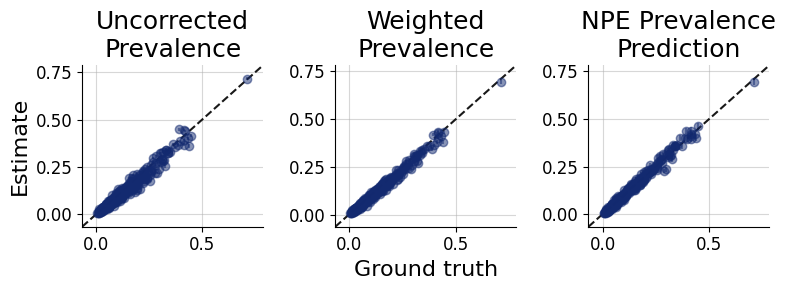

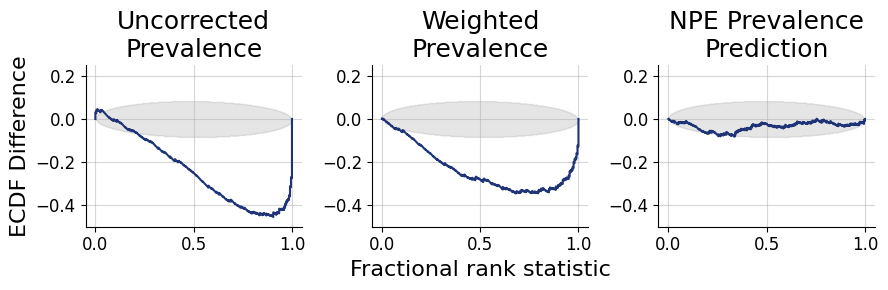

In [27]:
if len(param_names) == 1:
    estimates = np.concatenate((validation_data['reference_bootstrap'],
                                validation_data['reference_bootstrap_cor'],
                                posterior_samples['prevalence']), axis=-1)
    ground_truth = np.concatenate((validation_data['prevalence'],
                                   validation_data['prevalence'], validation_data['prevalence']), axis=-1)
    variable_names = ['Uncorrected\nPrevalence', 'Weighted\nPrevalence', 'NPE Prevalence\nPrediction']

    fig = bf.diagnostics.recovery(estimates, ground_truth, variable_names=variable_names, add_corr=False, figsize=(8, 3))
    ax = fig.get_axes()
    for i, a in enumerate(ax):
        if i != 1:
            a.set_xlabel("")
    plt.tight_layout()
    #fig.savefig(f'plots/prevalence_recovery_full.pdf', bbox_inches='tight')
    rmse_bf = bf.diagnostics.metrics.root_mean_squared_error(estimates, ground_truth, normalize=False)['values']
    print(rmse_bf)

    fig = bf.diagnostics.calibration_ecdf(estimates, ground_truth, difference=True,
                                          variable_names=variable_names, figsize=(9, 3))
    ax = fig.get_axes()
    for i, a in enumerate(ax):
        leg = a.get_legend()
        leg.set_visible(False)
        a.set_ylim(-0.5, 0.25)
        if i != 1:
            a.set_xlabel("")
    plt.tight_layout()
    #plt.savefig(f'plots/prevalence_ecdf_full.pdf', bbox_inches='tight')
    plt.show()

# Application to KoCo19 data

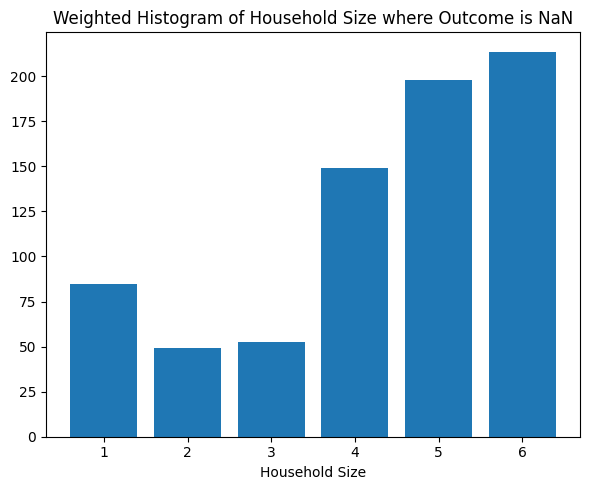

1
Uncorrected prevalence: 1.376568646277264, [0.98243436 1.75323751]
Corrected prevalence: 1.4634022692508206, [1.00994818 1.99881545]
NPE prevalence: 1.208273647353053, [0.79633659 1.86276204]


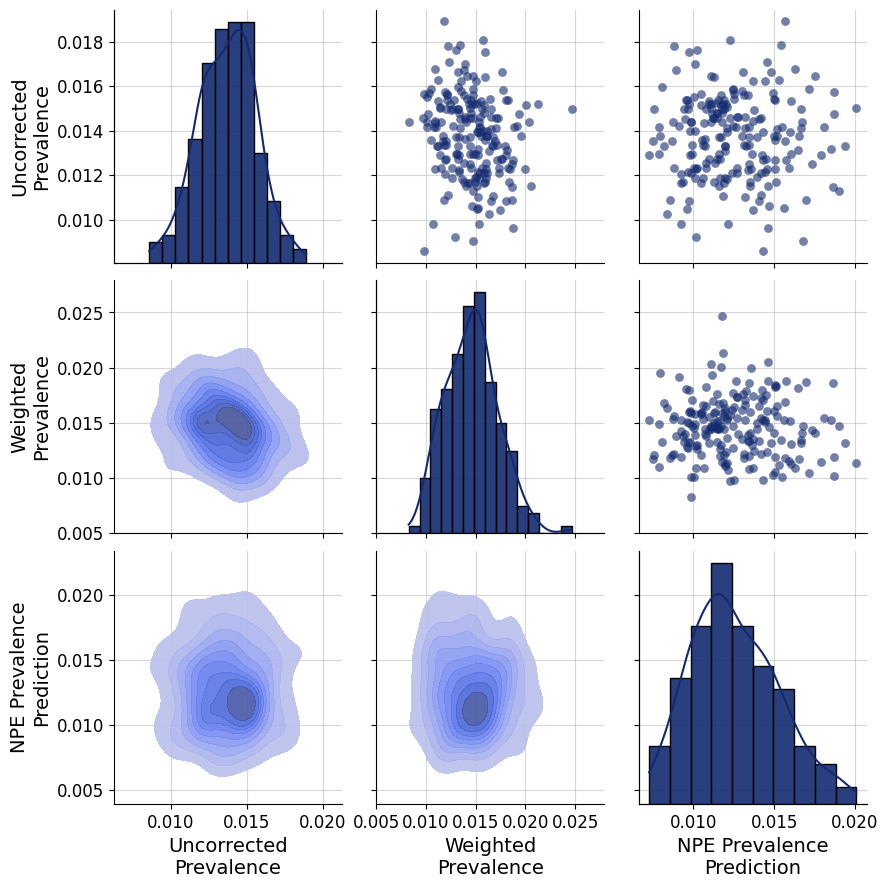

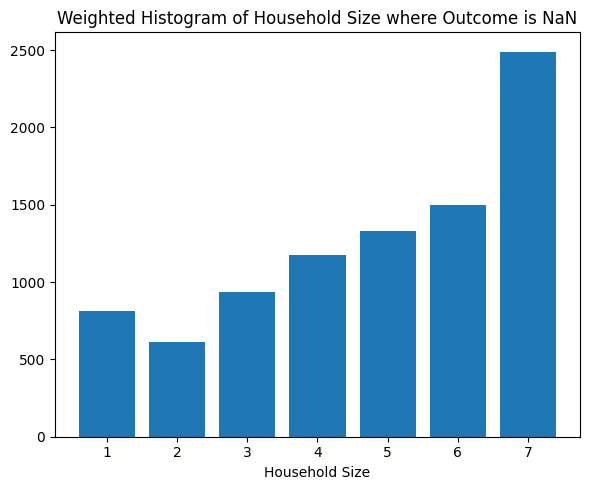

2
Uncorrected prevalence: 2.9633372065070773, [2.42133548 3.53982456]
Corrected prevalence: 2.788842468236795, [2.25637125 3.43059587]
NPE prevalence: 2.632938977330923, [1.91845858 3.67884438]


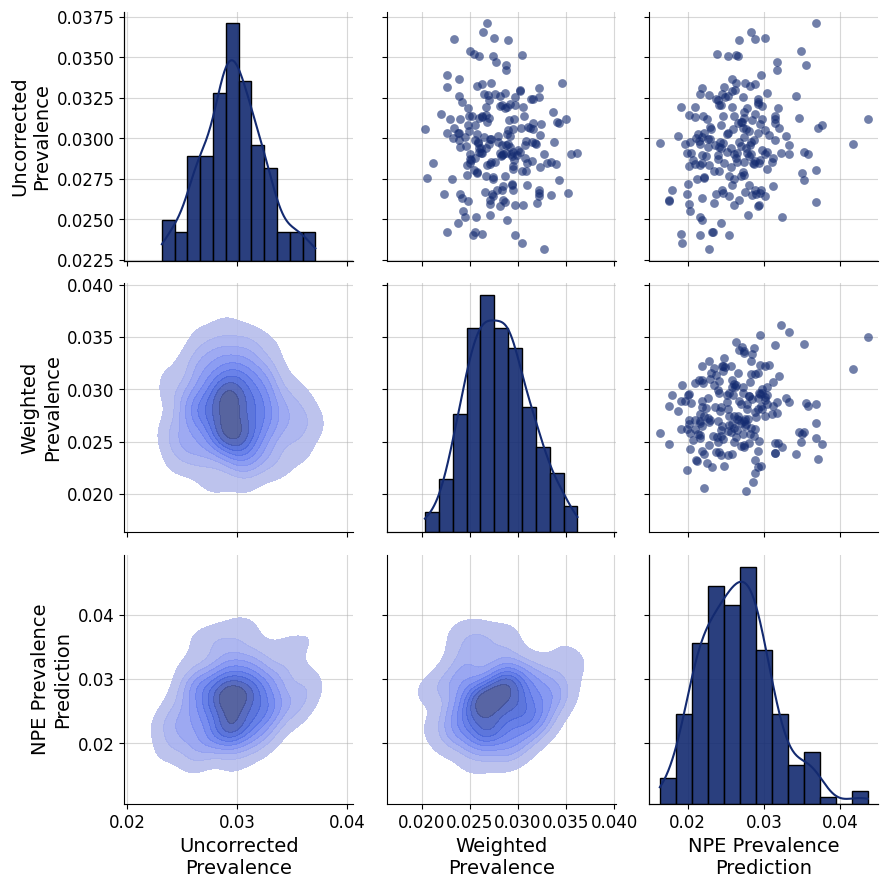

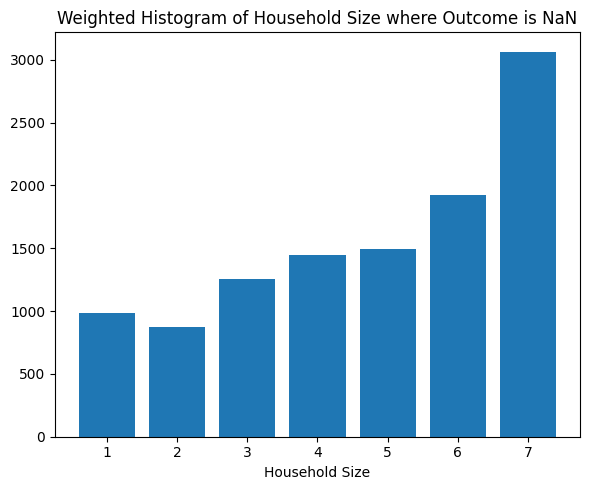

3
Uncorrected prevalence: 5.4494200932282775, [4.6710512  6.18395283]
Corrected prevalence: 5.439055691568755, [4.48673572 6.41330214]
NPE prevalence: 4.747919179499149, [3.62636856 6.09596469]


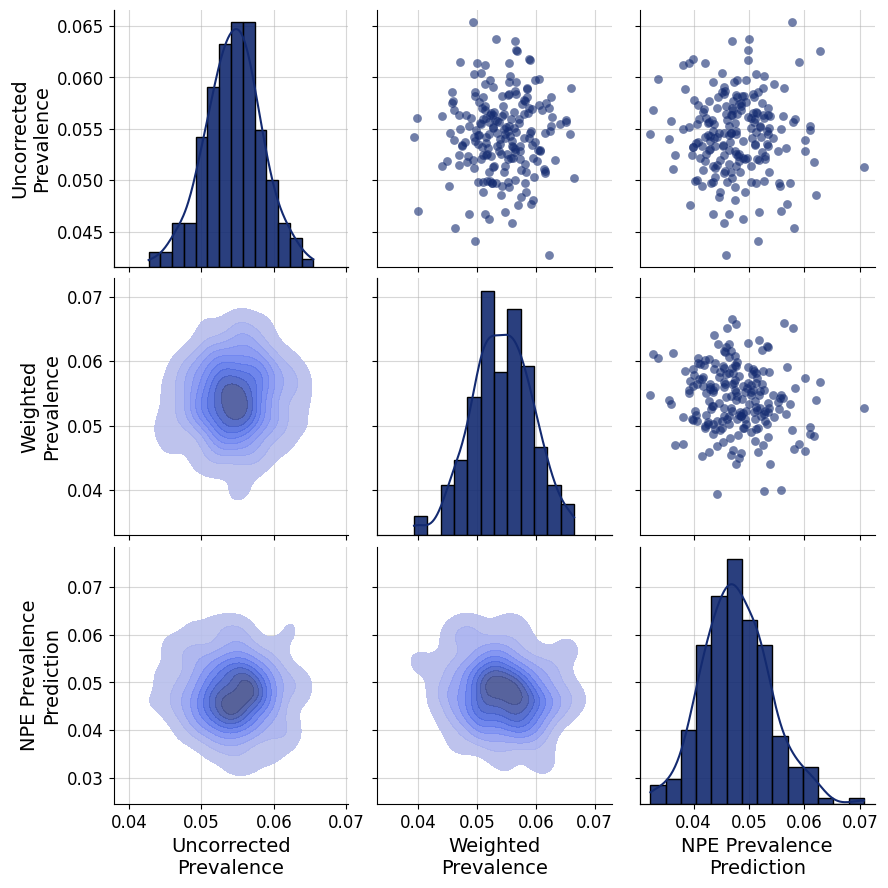

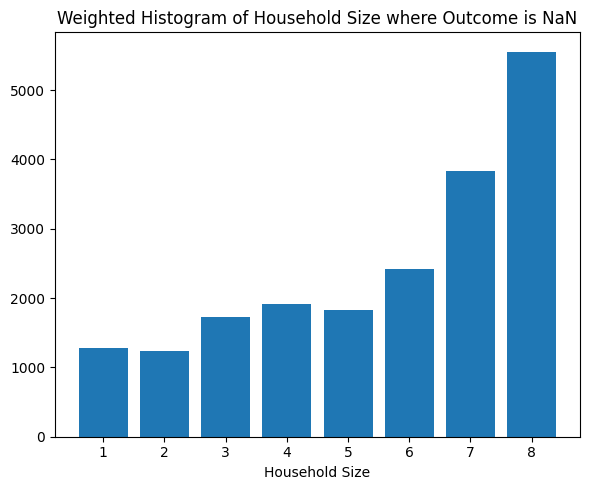

4
Uncorrected prevalence: 6.9687315314117315, [6.12510283 8.02109118]
Corrected prevalence: 7.0810854264335505, [5.91400296 8.29868572]
NPE prevalence: 6.385848671197891, [5.20135869 8.06490378]


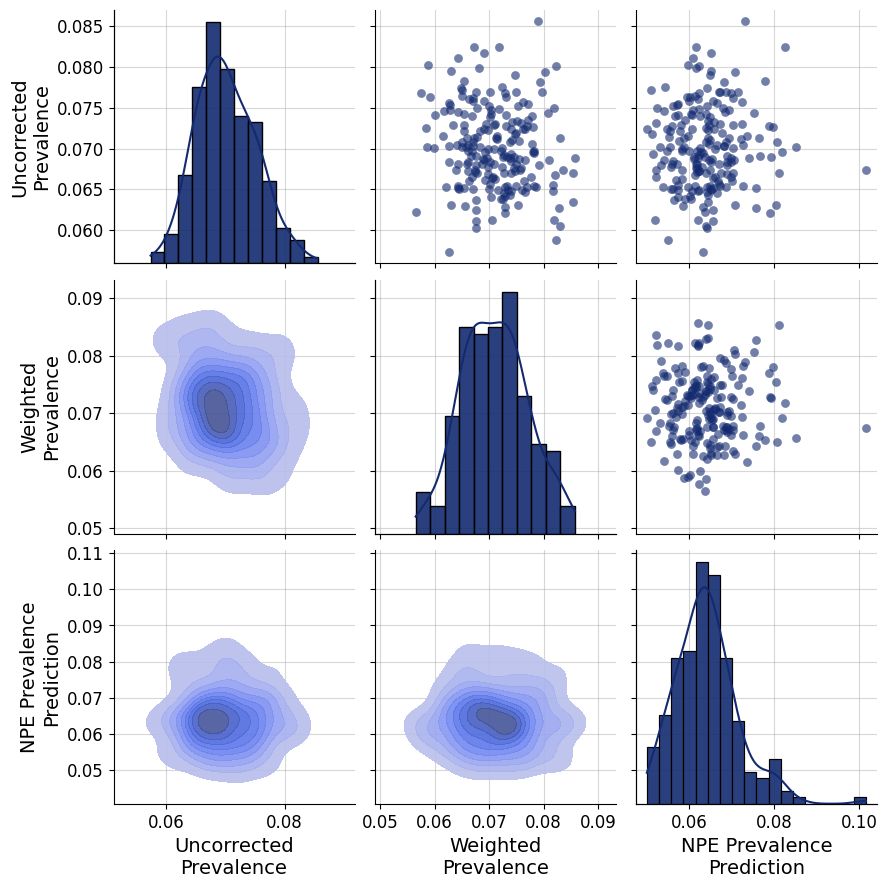

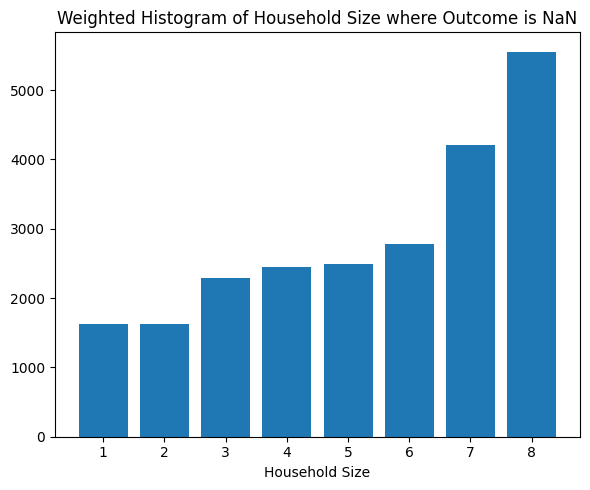

5
Uncorrected prevalence: 10.310616079884236, [ 9.45516145 11.389717  ]
Corrected prevalence: 10.084649024770618, [ 8.84574633 11.37744225]
NPE prevalence: 9.368589892983437, [ 7.68297071 11.78705355]


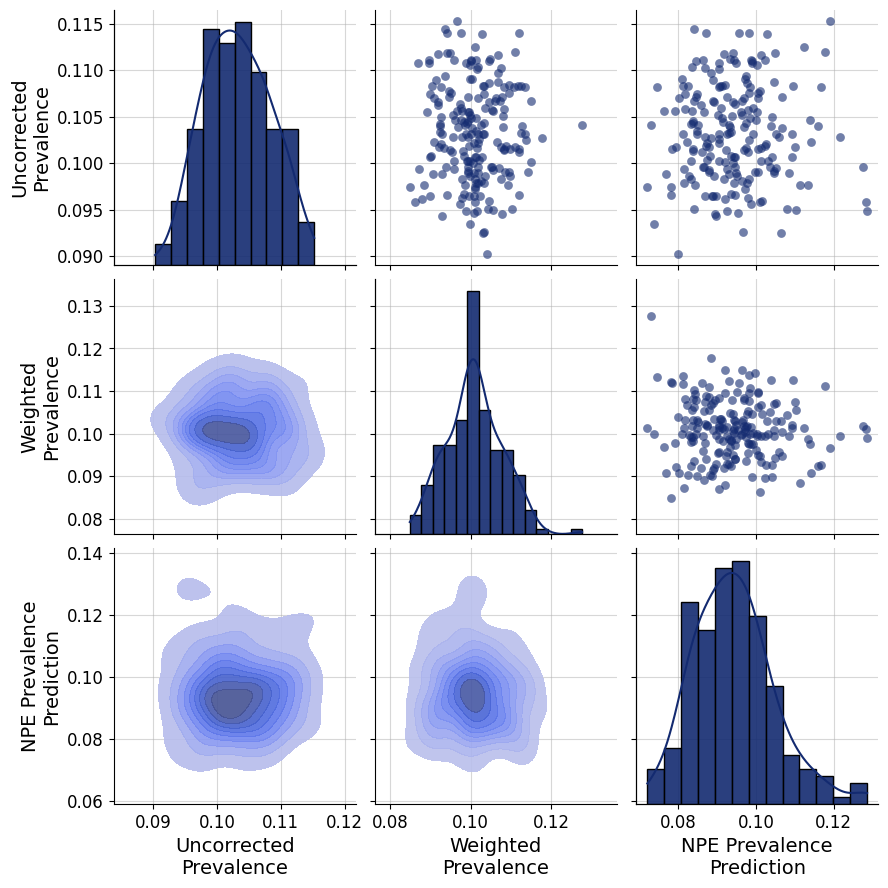

In [34]:
np.random.seed(42)
prev_list = []
prev_list_q = []
prev_list_samples = []
missing_round = []
for i in range(1, 6):
    koco_df = pd.read_csv(f'KoCo/koco19_T{i}.csv')  # column names: HH_ID, hh_size, pos, sex,age, timepoint

    # define bins and labels
    bins   = [0, 20, 35, 50, 65, 80, np.inf]
    labels = ['0-19', '20-34', '35-49', '50-64', '65-79', '80+']
    missing_round.append(sum(np.isnan(koco_df['pos'])) / len(koco_df) * 100)

    # create the age_group column
    koco_df['_age'] = koco_df['age']
    koco_df['age'] = pd.cut(koco_df['age'],
                             bins=bins,
                             labels=labels,
                             right=False).astype('object')  # intervals are [left, right)

    koco_df['gender'] = koco_df['sex'].map({'f': 'female', 'm': 'male'})
    koco_df['country'] = koco_df['birth_country']
    koco_df['h_size'] = koco_df['hh_size'].map({1: 'household_1', 2: 'household_2',
                                                 3: 'household_34', 4: 'household_34',
                                                 5: 'household_5+'})
    koco_df['household_id'] = pd.factorize(koco_df['HH_ID'])[0]

    # compute correlation of missingness with covariates
    hh_size_counts = koco_df['hh_size'].value_counts(normalize=True)
    missing_pos = koco_df[pd.isna(koco_df['pos'])]
    hh_size_missing = missing_pos['hh_size'].value_counts()
    aligned = hh_size_missing / hh_size_counts
    aligned = aligned.dropna().sort_index()
    plt.figure(figsize=(6, 5))
    plt.bar(aligned.index, aligned.values)
    plt.xlabel('Household Size')
    plt.title('Weighted Histogram of Household Size where Outcome is NaN')
    plt.tight_layout()
    #plt.savefig(f'plots/koco19_missing_household_size.pdf', bbox_inches='tight')
    plt.show()

    # rename columns
    koco_df['test_positive'] = koco_df['pos']
    koco_df.pop('HH_ID')
    koco_df.pop('hh_size')
    koco_df.pop('pos')
    koco_df.pop('sex')
    koco_df.pop('timepoint')
    koco_df.pop('birth_country')

    _, _, b_estimates, b_estimates_cor = estimate_prevalence(koco_df, bootstrap=True)
    uncorrected_quantile = np.quantile(b_estimates, [0.025, 0.975])
    corrected_quantile = np.quantile(b_estimates_cor, [0.025, 0.975])
    print(i)
    print(f"Uncorrected prevalence: {np.median(b_estimates)*100}, {uncorrected_quantile*100}")
    print(f"Corrected prevalence: {np.median(b_estimates_cor)*100}, {corrected_quantile*100}")

    # now with NPE
    koco_nn = convert_to_nn_input(koco_df, return_long=long_format)[np.newaxis]
    posterior_samples = workflow.sample(num_samples=b_estimates.shape[0], conditions=dict(sim_data=koco_nn))
    posterior_samples = posterior_samples['prevalence'].flatten()
    npe_quantile = np.quantile(posterior_samples, [0.025, 0.975])
    print(f"NPE prevalence: {np.median(posterior_samples)*100}, {npe_quantile*100}")

    prev_list.append([np.median(b_estimates), np.median(b_estimates_cor), np.median(posterior_samples)])
    prev_list_q.append([uncorrected_quantile, corrected_quantile, npe_quantile])
    prev_list_samples.append([b_estimates, b_estimates_cor, posterior_samples])

    bf.diagnostics.pairs_posterior(np.stack((b_estimates, b_estimates_cor, posterior_samples), axis=-1), variable_names=variable_names)
    plt.show()

prev_list = np.array(prev_list)
prev_list_q = np.array(prev_list_q)
prev_list_samples = np.array(prev_list_samples)

In [ ]:
(np.isnan(koco_df['pos'].values)*1.0).sum()

In [ ]:
np.corrcoef([0., 0., 0.], [1.0, 1.0, -1.0])

In [ ]:
# Plot violin plot
fig, ax = plt.subplots(figsize=(5, 3), tight_layout=True)
width = 0.15
offsets = [-width, 0, width]
labels = ['Unadjusted', 'Weighted', 'NPE']

for i, samples in enumerate(prev_list_samples.transpose(1, 0, 2)):
    pos = np.arange(5) + offsets[i]
    parts = ax.violinplot(
        [samples[t]*100 for t in range(5)],
        positions=pos,
        widths=width,
        showmeans=False,
        showmedians=True,
        showextrema=False,
    )
    # Label each set of violin bodies for legend
    for body in parts['bodies']:
        body.set_label(labels[i])
        break

ax.set_xticks(np.arange(5))
#ax.set_xticklabels(['T1', 'T2', 'T3', 'T4', 'T5'])
ax.set_xticklabels([f'T1\n({round(missing_round[0], 2)}%)', f'T2\n({round(missing_round[1], 2)}%)',
                    f'T3\n({round(missing_round[2], 2)}%)', f'T4\n({round(missing_round[3], 2)}%)',
                    f'T5\n({round(missing_round[4], 2)}%)'])
ax.set_xlabel('Round (Missingness in %)')
ax.set_ylabel('Prevalence (%)')
ax.set_title('KoCo19 Prevalence by Method')
fig.legend(loc='lower center', ncols=3, bbox_to_anchor=(0.5, -0.07))
#fig.savefig(f'plots/koco19_prevalence.pdf', bbox_inches='tight')
#ax.set_ylim(1,12)
plt.show()